In [ ]:
# kmap.py

AB = ['00', '01', '11', '10']
C  = ['0', '1']

F = [
    [1, 1],   # AB=00
    [1, 1],   # AB=01
    [0, 0],   # AB=11
    [0, 0],   # AB=10
]

# find the 1s
ones = []
for i, ab in enumerate(AB):
    for j, c in enumerate(C):
        if F[i][j] == 1:
            ones.append(ab + c)

# find the expression
expression = []
for var_idx, var_name in enumerate(['A', 'B', 'C']):
    bits = [cell[var_idx] for cell in ones]
    if all(b == '1' for b in bits):
        expression.append(var_name)
    elif all(b == '0' for b in bits):
        expression.append(var_name + "'")

print("F =", " ".join(expression))




In [ ]:
# verify against F
print("\nVerification:")
for i, ab in enumerate(AB):
    for j, c in enumerate(C):
        A  = int(ab[0])
        B  = int(ab[1])
        Cv = int(c)

        predicted = int(A == 0)   # F = A'

        match = "✓" if predicted == F[i][j] else "✗"
        print(f"  A={A} B={B} C={Cv}  F={F[i][j]}  predicted={predicted}  {match}")

### black and white


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 4x4 black and white image (0=black, 1=white)
image = np.array([
    [0, 0, 1, 1],
    [0, 0, 1, 1],
    [1, 1, 0, 0],
    [1, 1, 0, 0]
])

plt.imshow(image, cmap='gray')
plt.title("Black and White Image")
plt.show()

In [ ]:
# treat each pixel and its right neighbour as inputs A, B
# output F is the pixel itself

A = []
B = []
F = []

for row in range(4):
    for col in range(3):   # stop at 3 so we always have a right neighbour
        A.append(image[row, col])
        B.append(image[row, col + 1])
        F.append(image[row, col + 1])

A = [int(a) for a in A]
B = [int(b) for b in B]
F = [int(f) for f in F]

print(("A:", A))
print(("B:", B))
print(("F:", F))

In [ ]:
# build truth table
print("\nA | B | F")
print("-" * 10)
for i in range(len(A)):
    print(f"{int(A[i])} | {int(B[i])} | {int(F[i])}")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 10x10 checkerboard
image = np.zeros((10, 10), dtype=int)
for row in range(10):
    for col in range(10):
        if (row + col) % 2 == 0:
            image[row, col] = 1

# apply diagonal rule - F=1 if any diagonal is white
new_image = np.zeros((10, 10))


for row in range(10):
    for col in range(10):
        
        # Check diagonals safely. Only check if we aren't on the absolute edge.
        top_left =     (row > 0 and col > 0) and image[row-1, col-1] == 1
        top_right =    (row > 0 and col < 9) and image[row-1, col+1] == 1
        bottom_left =  (row < 9 and col > 0) and image[row+1, col-1] == 1
        bottom_right = (row < 9 and col < 9) and image[row+1, col+1] == 1
        
        # If any of those valid neighbors are 1, set the new square to 1
        if top_left or top_right or bottom_left or bottom_right:
            new_image[row, col] = 1

fig, axes = plt.subplots(1, 2)
axes[0].imshow(image, cmap='gray')
axes[0].set_title("Original")
axes[1].imshow(new_image, cmap='gray')
axes[1].set_title("After Rule")
plt.show()

#### gauss field

In [ ]:

from pgs_tools import make_gaussian_fields, make_lithotype_map

# generate a microstructure
field_1, field_2 = make_gaussian_fields(grid_size=50, seed_1=0, seed_2=1, len_scale_1=5, len_scale_2=10)
litho = make_lithotype_map(field_1, field_2, Mat1=0.60, Mat2=0.40, Mat3=0.0)

# convert to binary: material 0 vs everything else
binary = (litho > 0).astype(int)


import matplotlib.pyplot as plt
plt.imshow(binary, cmap='gray')
plt.title("Binary microstructure")
plt.show()

In [ ]:
A_list = []
B_list = []
C_list = []
D_list = []
F_list = []

rows, cols = binary.shape

for row in range(1, rows - 1):
    for col in range(1, cols - 1):
        A = binary[row-1, col-1]  # top-left
        B = binary[row-1, col+1]  # top-right
        C = binary[row+1, col-1]  # bottom-left
        D = binary[row+1, col+1]  # bottom-right
        F = binary[row, col]      # centre pixel

        A_list.append(int(A))
        B_list.append(int(B))
        C_list.append(int(C))
        D_list.append(int(D))
        F_list.append(int(F))

print(f"Total samples: {len(F_list)}")
print(f"F=1 count: {sum(F_list)}")
print(f"F=0 count: {F_list.count(0)}")

print( sum(F_list)/len(F_list))  # proportion of F=1
print( F_list.count(0) / len(F_list))  # proportion of F=0

In [ ]:
# find unique input combinations and their F values
from collections import defaultdict

counts = defaultdict(lambda: [0, 0])  # counts[ABCD] = [count_0, count_1]

for i in range(len(F_list)):
    key = (A_list[i], B_list[i], C_list[i], D_list[i])
    counts[key][F_list[i]] += 1

print("A B C D | F=0  F=1  | majority F")
print("-" * 40)
for key in sorted(counts.keys()):
    c0, c1 = counts[key]
    majority = 1 if c1 > c0 else 0
    print(f"{key} | {c0:4d}  {c1:4d} | {majority}")

we are only looking at diags for now to keep it abcd if we add all neighbours wed have abcdefgh and that is a big map, could be worth finding out which neighbours matter most not sure how to do that yet but could be worth it

## identity test


In [ ]:
# ── Two Image Mapping ─────────────────────────────────────

import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from pgs_tools import make_gaussian_fields, make_lithotype_map

# same fields for both images
field_1, field_2 = make_gaussian_fields(grid_size=500, seed_1=0, seed_2=1)

# image A - 60/40 split
litho_a = make_lithotype_map(field_1, field_2, Mat1=0.6, Mat2=0.4, Mat3=0.0)
image_a = (litho_a > 0).astype(int)

# image B - 40/60 split (same fields, different threshold)
litho_b = make_lithotype_map(field_1, field_2, Mat1=0.4, Mat2=0.6, Mat3=0.0)
image_b = (litho_b > 0).astype(int)

# ── Build K-map from A -> B (Fixed: 3x3 Neighborhood) ─────

rows, cols = image_a.shape
kmap = defaultdict(lambda: [0, 0])

for row in range(1, rows - 1):
    for col in range(1, cols - 1):
        # Grab all 9 pixels in a 3x3 grid
        top_L = int(image_a[row-1, col-1])
        top_M = int(image_a[row-1, col])
        top_R = int(image_a[row-1, col+1])

        mid_L = int(image_a[row, col-1])
        mid_M = int(image_a[row, col])      # Center pixel
        mid_R = int(image_a[row, col+1])

        bot_L = int(image_a[row+1, col-1])
        bot_M = int(image_a[row+1, col])
        bot_R = int(image_a[row+1, col+1])

        F = int(image_b[row, col])   # target output from image B
        
        # Create a detailed 9-part key
        key = (top_L, top_M, top_R, mid_L, mid_M, mid_R, bot_L, bot_M, bot_R)
        kmap[key][F] += 1

# ── Reconstruct B using K-map (Fixed: Matches 3x3 Key) ────

reconstructed = np.zeros_like(image_a)

for row in range(1, rows - 1):
    for col in range(1, cols - 1):
        # Grab all 9 pixels again for reconstruction
        top_L = int(image_a[row-1, col-1])
        top_M = int(image_a[row-1, col])
        top_R = int(image_a[row-1, col+1])

        mid_L = int(image_a[row, col-1])
        mid_M = int(image_a[row, col])
        mid_R = int(image_a[row, col+1])

        bot_L = int(image_a[row+1, col-1])
        bot_M = int(image_a[row+1, col])
        bot_R = int(image_a[row+1, col+1])

        key = (top_L, top_M, top_R, mid_L, mid_M, mid_R, bot_L, bot_M, bot_R)
        
        c0, c1 = kmap[key]
        # Pick the most common target pixel for this specific 3x3 pattern
        reconstructed[row, col] = 1 if c1 > c0 else 0

# fix borders
reconstructed[0, :]  = image_b[0, :]
reconstructed[-1, :] = image_b[-1, :]
reconstructed[:, 0]  = image_b[:, 0]
reconstructed[:, -1] = image_b[:, -1]

# ── Plot ──────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3)
axes[0].imshow(image_a, cmap='gray')
axes[0].set_title("Image A (input)")
axes[1].imshow(image_b, cmap='gray')
axes[1].set_title("Image B (target)")
axes[2].imshow(reconstructed, cmap='gray')
axes[2].set_title("Reconstructed B")
plt.show()

matches = np.sum(image_b[1:-1, 1:-1] == reconstructed[1:-1, 1:-1])
total = (rows - 2) * (cols - 2)
print(f"Match: {matches}/{total} pixels ({100*matches/total:.1f}%)")

### Two Image Mapping

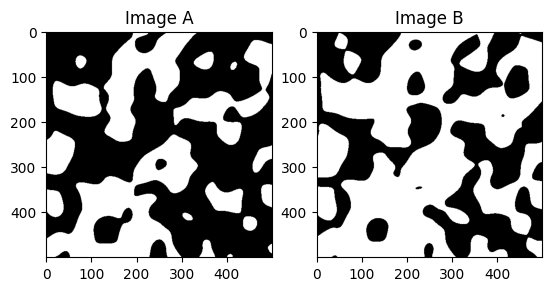

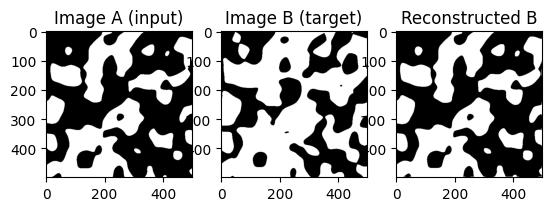

Match: 204708/248004 pixels (82.5%)


In [6]:
# ── Two Image Mapping ─────────────────────────────────────

import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from pgs_tools import make_gaussian_fields, make_lithotype_map

# same fields for both images
field_1, field_2 = make_gaussian_fields(grid_size=500, seed_1=0, seed_2=1)

# image A - 60/40 split
litho_a = make_lithotype_map(field_1, field_2, Mat1=0.6, Mat2=0.4, Mat3=0.0)
image_a = (litho_a > 0).astype(int)

# image B - 40/60 split (same fields, different threshold)
litho_b = make_lithotype_map(field_1, field_2, Mat1=0.4, Mat2=0.6, Mat3=0.0)
image_b = (litho_b > 0).astype(int)

fig, axes = plt.subplots(1, 2)
axes[0].imshow(image_a, cmap='gray')
axes[0].set_title("Image A")
axes[1].imshow(image_b, cmap='gray')
axes[1].set_title("Image B")
plt.show()


# ── Build K-map from A -> B ───────────────────────────────

rows, cols = image_a.shape
kmap = defaultdict(lambda: [0, 0])

for row in range(1, rows - 1):
    for col in range(1, cols - 1):
        A = int(image_a[row-1, col-1])
        B = int(image_a[row-1, col+1])
        C = int(image_a[row+1, col-1])
        D = int(image_a[row+1, col+1])
        E = int(image_a[row, col])
        F = int(image_b[row, col])   # output from image B
        key = (A, B, C, D)
        kmap[key][F] += 1

# ── Reconstruct B using K-map ─────────────────────────────

reconstructed = np.zeros_like(image_a)

for row in range(1, rows - 1):
    for col in range(1, cols - 1):
        A = int(image_a[row-1, col-1])
        B = int(image_a[row-1, col+1])
        C = int(image_a[row+1, col-1])
        D = int(image_a[row+1, col+1])
        E = int(image_a[row, col])
        key = (A, B, C, D)
        c0, c1 = kmap[key]
        reconstructed[row, col] = 1 if c1 > c0 else 0

# fix borders
reconstructed[0, :]  = image_b[0, :]
reconstructed[-1, :] = image_b[-1, :]
reconstructed[:, 0]  = image_b[:, 0]
reconstructed[:, -1] = image_b[:, -1]

# ── Plot ──────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3)
axes[0].imshow(image_a, cmap='gray')
axes[0].set_title("Image A (input)")
axes[1].imshow(image_b, cmap='gray')
axes[1].set_title("Image B (target)")
axes[2].imshow(reconstructed, cmap='gray')
axes[2].set_title("Reconstructed B")
plt.show()

matches = np.sum(image_b[1:-1, 1:-1] == reconstructed[1:-1, 1:-1])
total = (rows - 2) * (cols - 2)
print(f"Match: {matches}/{total} pixels ({100*matches/total:.1f}%)")

## Summary — Two Image Mapping

We built a K-map that maps pixel neighbourhoods from image A to pixel values in image B.

Key findings:
- Two independent random samples: ~60% match (K-map learns nothing real)
- Same fields, different thresholds: ~83% match (K-map learns the boundary shift)

The K-map only finds a meaningful rule when B is genuinely derived from A locally.
Next step: map a generated PGS image to a real target microstructure (ThreePhase.tif).

The K-map cannot find a meaningful mapping between two unrelated images.
With only 16 possible neighbourhood combinations (4 binary inputs), the K-map
defaults to the majority class and effectively just copies image A.

This does NOT mean K-maps are useless for this project. What we have shown is:

1. The K-map works perfectly as an identity (100% match)
2. The K-map captures spatial correlation structure (shown earlier with len_scale)
3. The K-map fails when there is no genuine local relationship between A and B

The meaningful use case remains:
- Use the K-map as a fingerprint of a microstructure
- Compare fingerprints across different PGS parameters
- See if fingerprint similarity correlates with parameter similarity

Next step: load ThreePhase.tif and extract its K-map fingerprint,
then compare against generated images with different parameters.